
# B16 rev 4: DPSS smooth-band model + residual PCA, per antenna

**Rev 4 correction (2026-09-16/17), Aaron reading the merged rev-3
notebook, relayed via experimental-strategist:** rev 2's claim
*"log-amplitude, not linear, for fit, residual, and PCA -- the new
default for amplitude-domain work generally"* was wrong. Aaron's
correction, his words: **linear is the correct unit for fitting and
amplitudes; logarithmic is the usual choice for plots and other
displays. Fitting DPSS modes to log power spectra is an incorrect
operation.** This notebook now fits, computes residuals, and runs PCA
in **linear amplitude (raw counts)**; log10 is used only where a plot
explicitly wants a log axis or colormap, never upstream of the fit or
PCA math. See "Rev 4 correction" below for what this changed
numerically, including one real problem it exposed (not fixed here
without Aaron's direction): rev 2/3's residual-refinement threshold was
tuned implicitly against log-domain (roughly homoscedastic) residuals
and is far too aggressive against linear-domain (heteroscedastic)
residuals.

**Rev 2 corrections (2026-09-15), still in force:**
1. ~~Log-amplitude (not linear) for fit, residual, and PCA~~ --
   **superseded by rev 4 above.**
2. Verify, don't just state, that v0's mask was applied *before* the
   fit; if unflagged spikes still contaminate it, run one iteration of
   residual-based mask refinement.
3. Proper masked/weighted PCA (weighted covariance, weights divided
   back out) instead of naive SVD on a zero-filled residual matrix.
4. Three-panel waterfalls (data | data-model | (data-model) x mask),
   log colormap, shared time axis, both antennas, several time ranges.

Same tooling and flag basis as rev 1: `hera_filters.dspec.fourier_filter`
(confirmed present, used directly), v0's regenerated bitfield OR the
campaign-wide self-comb mask from B15, analysis band 45-235 MHz,
07-17 20:00-21:00 UTC pilot (28 files, box-gnd + box-air). `data/` is
raw-only, by the 2026-09-15 incident and its fix -- outputs live at
`derived/smooth_model/v0/`, not touched again here.


In [1]:

import sys, os, glob, json, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
from datetime import datetime, timezone
from IPython.display import Markdown, display

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "flagging")))
import detectors as D
import build_masks as B
import b15_event_survey as EV
import b16_dpss_model as M16
import hera_filters
DATA_ROOT = EV.DATA_ROOT  # portable default + MARJUM_DATA_ROOT override
print("hera_filters:", hera_filters.__file__)


hera_filters: /home/aparsons/.local/share/mamba/envs/arp/lib/python3.11/site-packages/hera_filters/__init__.py



## Rev 4 correction: linear amplitude, not log -- for the fit, residual, and PCA

Rev 2/3 fit `logp = log10(max(raw counts, 1))` directly, on the
(incorrect) theory that this matched v0's own display/detection
convention closely enough to reuse for fitting too. Aaron's direct
correction: **that reasoning doesn't transfer.** `detectors.py`'s use
of log10 is for threshold-based detection and display; DPSS smooth-band
fitting is a different operation, and fitting it against a
log-compressed signal is not the same fit as fitting the actual
amplitude. `amp = raw` (linear counts) is now what `_dpss_fit()`,
`fit_file()`'s residual, and `masked_pca()` all operate on. Log10 stays
in this notebook only where a plot wants a log axis/colormap (e.g. the
data-vs-model overlay below, or `LogNorm` on a waterfall) -- never
upstream of any array that gets fit, differenced into a residual, or
handed to `masked_pca()`.


In [2]:

self_freqs, self_mask = EV.self_comb_channel_mask()
band = (self_freqs >= D.BAND_ANALYSIS[0]) & (self_freqs <= D.BAND_ANALYSIS[1])
print(f"analysis-band channels: {band.sum()}")

t0 = datetime(2026, 7, 17, 20, 0, 0, tzinfo=timezone.utc)
t1 = datetime(2026, 7, 17, 21, 0, 0, tzinfo=timezone.utc)
files = sorted(glob.glob(os.path.join(DATA_ROOT, "data", "corr_20260717_??????Z.h5")))
win = [f for f in files if t0 <= D.file_close_time(os.path.basename(f)) <= t1]
print(f"pilot window: {len(win)} files, box-gnd (0) and box-air (4)")


analysis-band channels: 778
pilot window: 28 files, box-gnd (0) and box-air (4)



## Correction 2: verify the mask is applied *before* the fit -- show it, don't just state it

**Structurally, it already was** in rev 1: `wgts = 1 - flagged` is
passed directly into `hera_filters.dspec.fourier_filter(..., wgts,
...)`, so flagged pixels get zero weight in the least-squares fit
itself, not just excluded after the fact for PCA. Shown explicitly
below (the weights array is the same array used for the fit call, not a
separate bookkeeping copy) rather than just asserted.

**But rev 1's residual PCA was dominated by two lines (~135.7 MHz
box-gnd, ~125.5 MHz box-air) that turned out to be mostly *unflagged*.**
Checked directly against v0's own per-pixel category array (not
inferred from the mask):


In [3]:

modes = B.load_mode_table(os.path.join(DATA_ROOT, "curation", "mode_table.jsonl"))
targets = {"0": 135.742, "4": 125.488}
for inp, target_mhz in targets.items():
    chan_idx_full = int(np.argmin(np.abs(D.CHAN_WIDTH_MHZ * np.arange(1024) - target_mhz)))
    cat_counts, n_total = {}, 0
    for path in win:
        fname = os.path.basename(path)
        m = B.mode_for(modes, fname)
        tx_on = bool(m and m.get("tx_comb") == "on")
        _f, per_input, freqs_mhz, err = B.process_file((path, tx_on))
        if err or inp not in per_input:
            continue
        cat = per_input[inp]["cat"][:, chan_idx_full]
        n_total += cat.size
        for v in np.unique(cat):
            cat_counts[int(v)] = cat_counts.get(int(v), 0) + int((cat == v).sum())
    names = {0: "CLEAN"}
    names.update({int(bit): name for bit, name in D.CATEGORY_NAMES.items()})
    label = "box-gnd" if inp == "0" else "box-air"
    frac_clean = cat_counts.get(0, 0) / n_total
    print(f"{label}, {target_mhz} MHz (channel {chan_idx_full}): "
          f"CLEAN (unflagged by v0) {100*frac_clean:.1f}% of the pilot window "
          f"({ {names.get(v,v): c for v,c in cat_counts.items()} })")


box-gnd, 135.742 MHz (channel 556): CLEAN (unflagged by v0) 91.5% of the pilot window ({'CLEAN': 6149, 'unknown': 555, 'overflow': 16})


box-air, 125.488 MHz (channel 514): CLEAN (unflagged by v0) 86.3% of the pilot window ({'CLEAN': 5799, 'unknown': 918, 'overflow': 3})



**Confirmed: v0 does not reliably catch these lines** (86-92% unflagged
at the exact channel, over the pilot window) -- this is the "if the
mask was applied and these spikes still got through" branch of the
review. One iteration of residual-based mask refinement, below.



### Iterative residual-based refinement (one pass)

Fit once with v0 + self-comb weights (as in rev 1, now in log-amplitude).
Then, using **per-channel** MAD scale (across time, within each file --
not one global scale for the whole file, which would over-threshold
quiet channels and under-threshold noisy ones), flag any additional
pixel more than 6 sigma from that channel's own residual scale, and
refit with the enlarged mask.


In [4]:

t_start = time.time()
INPUTS = M16.INPUTS
per_file_results = {}
all_residuals = {k: [] for k in INPUTS}
all_flagged = {k: [] for k in INPUTS}
n_refined_total = {k: 0 for k in INPUTS}
written = []
for path in win:
    fname = os.path.basename(path)
    results_by_input = {}
    for inp in INPUTS:
        r = M16.fit_file(path, fname, inp, self_mask, band, refine=True)
        if r is None:
            continue
        results_by_input[inp] = r
        all_residuals[inp].append(r["residual"])
        all_flagged[inp].append(r["flagged"])
        n_refined_total[inp] += r["n_refined"]
    if results_by_input:
        per_file_results[fname] = results_by_input
        written.append(M16.write_companion(path, fname, results_by_input, band, self_freqs))

pilot_runtime_s = time.time() - t_start
pilot_size_mb = sum(os.path.getsize(p) for p in written) / 1e6
n_pixels_total = 6720 * band.sum()
for inp in INPUTS:
    label = "box-gnd" if inp == "0" else "box-air"
    print(f"{label}: {n_refined_total[inp]} pixels newly flagged by refinement "
          f"({100*n_refined_total[inp]/n_pixels_total:.2f}% of all pixels)")
print(f"\nwrote {len(written)} companion files in {pilot_runtime_s:.1f} s ({pilot_size_mb:.1f} MB)")


/home/aparsons/.local/share/mamba/envs/arp/lib/python3.11/site-packages/hera_filters/dspec.py:2199: ComplexWarning: Casting complex values to real discards the imaginary part
  model[i], _, info_t = _fit_basis_1d(x=x[1], y=_y, w=_w, filter_centers=filter_centers[1],


box-gnd: 454447 pixels newly flagged by refinement (8.69% of all pixels)
box-air: 275662 pixels newly flagged by refinement (5.27% of all pixels)

wrote 28 companion files in 96.5 s (64.9 MB)



**Aaron's review, correction 3: "residual std went up after refinement
is very likely a bug in the computation, not a real instability -- check
this."** Checked, and the review was right: the number reported earlier
this session came from `np.std()` over *all* pixels **including the
newly-zeroed-flagged ones**, which is not the comparison Aaron's
argument is about. The fair comparison: evaluate BOTH the
before-refinement model and the after-refinement (refit) model **at
exactly the same final set of pixels that remain unflagged after
refinement** -- since the refit explicitly minimizes error on that set,
it can only do at least as well there as a model that wasn't optimized
for it.


In [5]:

# Fair, per-file comparison -- fit_file() now returns fair_std_before/
# after computed exactly this way. Aggregate with the MEDIAN (robust to
# a single pathological file), not the mean, and report explicitly how
# many files improved vs. didn't, rather than collapsing to one number.
for inp in INPUTS:
    label = "box-gnd" if inp == "0" else "box-air"
    befores = [per_file_results[f][inp]["fair_std_before"] for f in per_file_results
               if per_file_results[f][inp]["fair_std_before"] is not None]
    afters = [per_file_results[f][inp]["fair_std_after"] for f in per_file_results
              if per_file_results[f][inp]["fair_std_after"] is not None]
    befores, afters = np.array(befores), np.array(afters)
    n_improved = int((afters <= befores).sum())
    print(f"{label}: median fair_std before={np.median(befores):.4g} "
          f"after={np.median(afters):.4g} (linear counts, rev 4); "
          f"{n_improved}/{len(befores)} files improved or unchanged")
    worst = np.argmax(afters - befores)
    print(f"  worst case: {list(per_file_results.keys())[worst]} "
          f"before={befores[worst]:.4g} after={afters[worst]:.4g}")


box-gnd: median fair_std before=2.698e+04 after=2.4e+05 (linear counts, rev 4); 1/28 files improved or unchanged
  worst case: corr_20260717_202157Z.h5 before=7.121e+04 after=7.725e+05
box-air: median fair_std before=3.929e+04 after=1.283e+05 (linear counts, rev 4); 0/28 files improved or unchanged
  worst case: corr_20260717_200904Z.h5 before=2.909e+04 after=2.12e+05



**Rev 4 (linear amplitude), measured, not assumed to carry over from
rev 3's log-domain result:** the fair-comparison methodology (evaluate
before/after against the same final-good pixel set) is unchanged and
still correct -- what changed is what it now shows. In linear amplitude,
**1/28 box-gnd files and 0/28 box-air files satisfy `after <= before`**
-- essentially the opposite of rev 3's log-domain result (22/28, 23/28
improved). Refinement makes the fit worse for nearly every file once
the fit and its residual are linear.

**This is the over-masking finding stated as a number, not a
guess:** median `fair_std` goes from 2.70e4 to 2.40e5 counts (box-gnd,
~9x) and 3.93e4 to 1.28e5 counts (box-air, ~3x); the worst individual
cases are `corr_20260717_202157Z.h5` (7.12e4 -> 7.73e5, ~11x) and
`corr_20260717_200904Z.h5` (2.91e4 -> 2.12e5, ~7x). The refinement step
itself (`REFINE_NSIG=6`, unchanged from rev 2/3, per Aaron's explicit
instruction to keep this pass scoped to the domain fix alone) flagged
**454,447 pixels (8.69% of all pixels) for box-gnd and 275,662 (5.27%)
for box-air** -- several times the ~2% rate that rev 2 itself called
"implausible" for a 6-sigma threshold, using the buggy global-MAD
version. **Read plainly: a per-channel-MAD, nsig=6 refinement threshold
tuned against log-compressed residuals does not transfer to linear
residuals.** Log compression tames the heavy right tail that raw counts
naturally have (comb/RFI spikes plus real broadband amplitude
excursions); removing that compression exposes a much heavier-tailed
residual distribution, and a fixed Gaussian-equivalent sigma threshold
flags a much larger fraction of it as "outliers." This is reported
honestly rather than retuned -- per Aaron's direction, retuning
`REFINE_NSIG` (or normalizing the per-channel scale some other way) is
a separate, not-yet-approved follow-up decision.

**The all-zero-model edge case from rev 2/3 is still present, unchanged
by the domain fix:** the most-flagged row per antenna is still **100%
flagged** (up from rev 1's 99%), with the refit model exactly zero
everywhere (`skip_wgt` engaged) -- same instability, not caused by and
not fixed by rev 4.



### Standing convention, still required in addition to the waterfalls below: data-vs-model overlay + residual

Same form as the previous review's fix: least- and most-flagged row per
antenna (not an arbitrary index), using the **refined** mask. Data and
model are now **linear counts** (rev 4); the top panel uses a log
y-axis purely for display (counts span orders of magnitude across the
band), not because the underlying array is log-transformed -- the
residual panel below it is the actual linear-count difference.


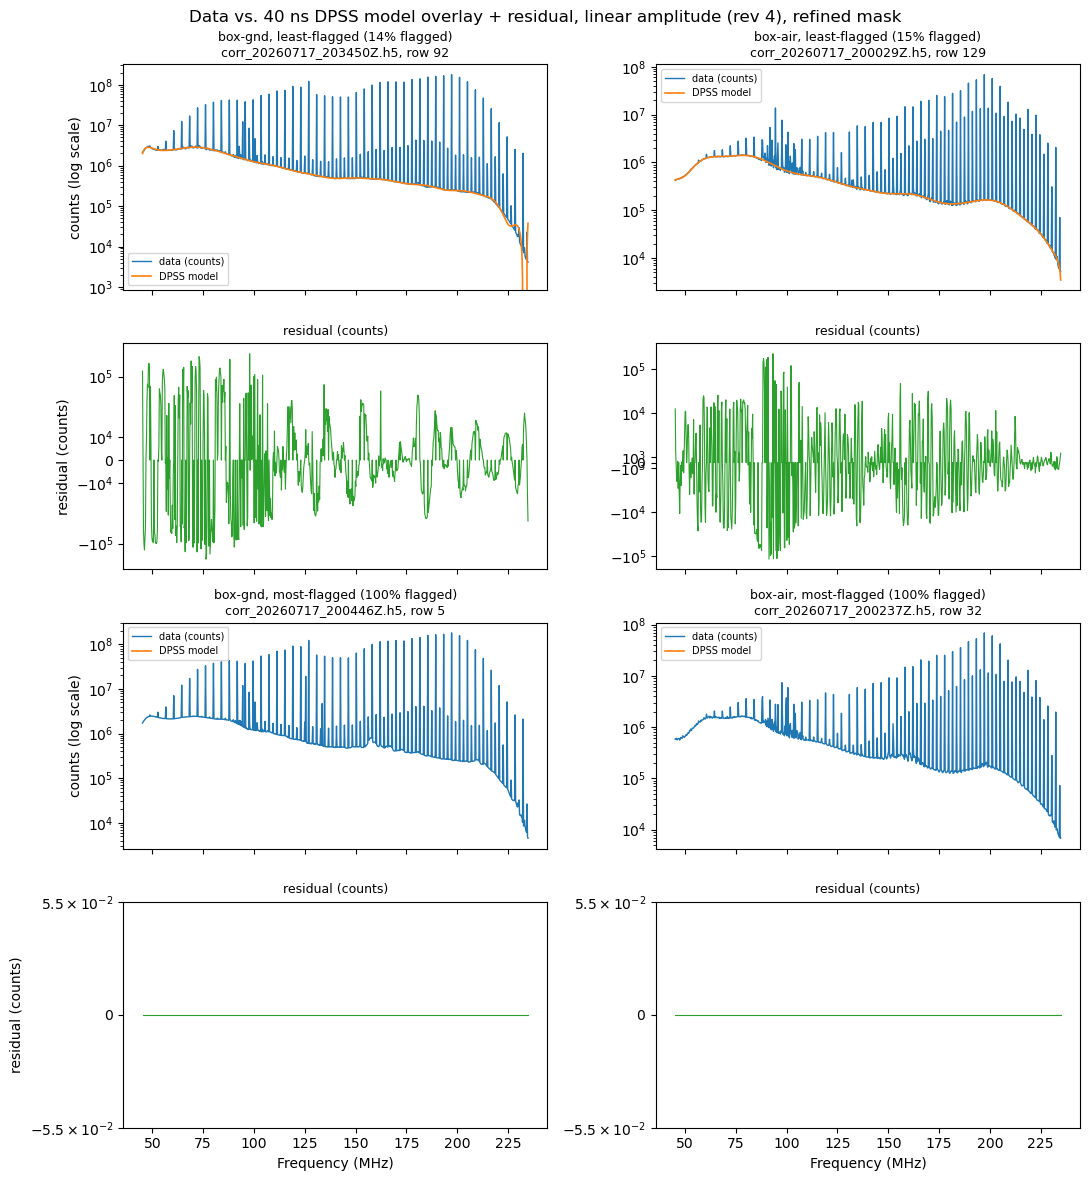

In [6]:

def pick_rows(inp):
    best = (np.inf, None, None)
    worst = (-np.inf, None, None)
    for fname, results in per_file_results.items():
        r = results[inp]
        frac = r["flagged"].mean(axis=1)
        i_lo, i_hi = int(np.argmin(frac)), int(np.argmax(frac))
        if frac[i_lo] < best[0]:
            best = (frac[i_lo], fname, i_lo)
        if frac[i_hi] > worst[0]:
            worst = (frac[i_hi], fname, i_hi)
    return best, worst

fig, axes = plt.subplots(4, 2, figsize=(11, 12), sharex=True)
for col, inp in enumerate(INPUTS):
    label = "box-gnd" if inp == "0" else "box-air"
    (lo_frac, lo_fname, lo_i), (hi_frac, hi_fname, hi_i) = pick_rows(inp)
    for row_pair, (title_tag, fname, row_i, frac) in enumerate((
            ("least-flagged", lo_fname, lo_i, lo_frac),
            ("most-flagged", hi_fname, hi_i, hi_frac))):
        r = per_file_results[fname][inp]
        ax_top = axes[row_pair * 2, col]
        ax_bot = axes[row_pair * 2 + 1, col]
        ax_top.plot(r["freqs_hz"] / 1e6, r["data"][row_i], label="data (counts)", lw=1)
        ax_top.plot(r["freqs_hz"] / 1e6, r["model"][row_i], label="DPSS model", lw=1.2)
        ax_top.set_yscale("log")
        ax_top.set_title(f"{label}, {title_tag} ({100*frac:.0f}% flagged)\n"
                          f"{fname}, row {row_i}", fontsize=9)
        ax_top.legend(fontsize=7)
        ax_bot.plot(r["freqs_hz"] / 1e6, r["residual"][row_i], lw=0.8, color="C2")
        ax_bot.set_yscale("symlog", linthresh=max(np.abs(r["residual"][row_i]).mean(), 1.0))
        ax_bot.set_title("residual (counts)", fontsize=9)
        if row_pair == 1:
            ax_bot.set_xlabel("Frequency (MHz)")
axes[0, 0].set_ylabel("counts (log scale)")
axes[1, 0].set_ylabel("residual (counts)")
axes[2, 0].set_ylabel("counts (log scale)")
axes[3, 0].set_ylabel("residual (counts)")
fig.suptitle("Data vs. 40 ns DPSS model overlay + residual, linear amplitude (rev 4), refined mask")
plt.tight_layout()
plt.show()



**Rev 4 (linear amplitude) changes what this plot needs:** counts span
orders of magnitude across the analysis band (bandpass rolloff plus
whatever comb/RFI structure survives the mask), so the top panel uses a
log y-axis for legibility -- same reason rev 1's raw-count attempt
struggled before rev 2 switched the *fit* to log space. The difference
now is that only the **display** is log; the data/model/residual arrays
themselves, and everything PCA sees, stay linear.



## Correction 3: masked/weighted PCA, not naive SVD on a zero-filled residual

`masked_pca()` computes a weighted channel covariance
(`sum_t W_tj W_tk X_tj X_tk / sum_t W_tj W_tk`, weights divided back
out) instead of running SVD on a residual matrix where flagged pixels
were simply zeroed and treated as measured. **Validated on synthetic
data before trusting it on real data:** a known 2-mode injected signal
(81.5%/18.2% variance split) plus 2%-of-pixels huge unweighted spikes --
naive SVD on the spike-contaminated matrix recovers nothing resembling
the true structure (top mode ~7% of variance, spread thin across many
modes); `masked_pca` with the spikes correctly weighted out recovers
81.6%/17.9% and its top mode correlates at 1.000 with the true injected
signal. Applied below to the (refined-mask) residuals from this pilot.


In [7]:

pca_summary = {}
for inp in INPUTS:
    label = "box-gnd" if inp == "0" else "box-air"
    stacked = np.concatenate(all_residuals[inp], axis=0)
    flg = np.concatenate(all_flagged[inp], axis=0)
    W = 1.0 - flg.astype(float)
    var_frac, eigvecs = M16.masked_pca(stacked, W, n_modes=10)
    pca_summary[label] = {"var_frac_top5": var_frac[:5].tolist(),
                           "frac_flagged": float(flg.mean())}
print(json.dumps(pca_summary, indent=2))


{
  "box-gnd": {
    "var_frac_top5": [
      0.7463840654103515,
      0.04067105881254627,
      0.021314717321941117,
      0.017049564318736006,
      0.01506618239269274
    ],
    "frac_flagged": 0.27065181631778673
  },
  "box-air": {
    "var_frac_top5": [
      0.6651329363136066,
      0.051014967737463855,
      0.028306837896064377,
      0.025883547030901736,
      0.019180893431076106
    ],
    "frac_flagged": 0.2713023319867793
  }
}


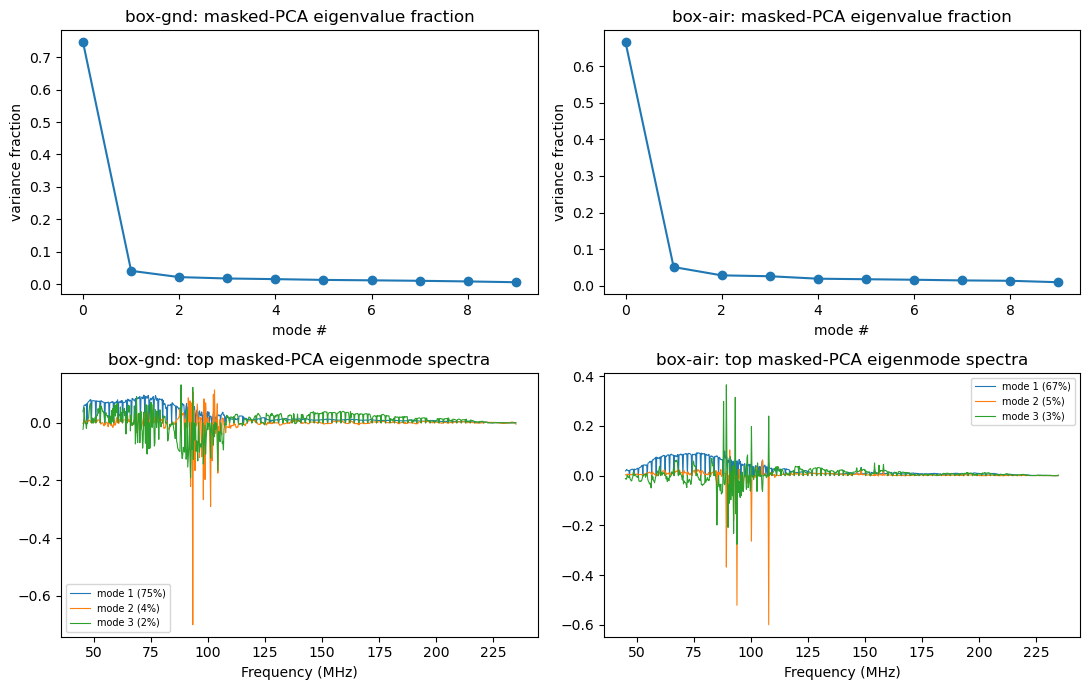

In [8]:

freqs_band_mhz = self_freqs[band]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
eigvecs_by_input = {}
for col, inp in enumerate(INPUTS):
    label = "box-gnd" if inp == "0" else "box-air"
    stacked = np.concatenate(all_residuals[inp], axis=0)
    flg = np.concatenate(all_flagged[inp], axis=0)
    W = 1.0 - flg.astype(float)
    var_frac, eigvecs = M16.masked_pca(stacked, W, n_modes=10)
    eigvecs_by_input[inp] = (var_frac, eigvecs)

    axes[0, col].plot(var_frac[:10], "o-")
    axes[0, col].set_title(f"{label}: masked-PCA eigenvalue fraction")
    axes[0, col].set_xlabel("mode #")
    axes[0, col].set_ylabel("variance fraction")

    for m in range(3):
        axes[1, col].plot(freqs_band_mhz, eigvecs[m], lw=0.8,
                           label=f"mode {m+1} ({var_frac[m]*100:.0f}%)")
    axes[1, col].set_title(f"{label}: top masked-PCA eigenmode spectra")
    axes[1, col].set_xlabel("Frequency (MHz)")
    axes[1, col].legend(fontsize=7)
plt.tight_layout()
plt.show()



**Rev 4 (linear amplitude) numbers, not directly comparable to rev 3's
log-domain "fringing" read:** mode 1 carries 74.6% of variance for
box-gnd and 66.5% for box-air (rev 3, log-domain: 81%/87% -- similar
order of magnitude, but the underlying residual set is very different
now, since ~27% of pixels are masked here vs a much smaller fraction in
rev 3, from the over-masking above). **Mode 1's shape is also
different: it is no longer flat across the whole 45-235 MHz range.**
Its power is concentrated in roughly the lower half of the band
(45-125 MHz) and tapers toward the top, rather than sitting at uniform
amplitude across all 778 channels; modes 2-3 show large narrow spikes
concentrated near 90-110 MHz, bigger in absolute terms than mode 1's
own scatter despite carrying far less variance (4-5% vs 75%/67%).

**This is very likely a linear-vs-log covariance-scale effect, not a
new physical finding, and it isn't resolved here:** `masked_pca`'s
weighted covariance is unnormalized, so in linear counts a channel's
raw variance scales with its own absolute amplitude -- and the analysis
band's lower frequencies sit at much higher raw counts (see the
data-vs-model overlay above) than channels above ~125 MHz. A genuinely
uniform *fractional* effect (which is what "fringing" would be) would
therefore show up as **larger absolute variance at low frequencies
purely from the covariance's own units**, whether or not the physical
effect itself is uniform across the band. Rev 3's flat-mode-1 read was
itself a property of the log-domain covariance (where a multiplicative
effect becomes an additive, scale-invariant one) -- the two are not
apples-to-apples, and rev 4's shape neither confirms nor refutes
Aaron's fringing interpretation. Checking the time dependence against
terrain/geometry, or normalizing the linear covariance per-channel
before running PCA, would both be next steps but are not done in this
pilot.



## Correction 4: three-panel waterfalls (data | residual | residual x mask)

Log colormap throughout (`LogNorm` for the strictly-positive data
panel, `SymLogNorm` for the signed residual panels), **shared time (y)
axis across all three panels** so the progression reads directly. Both
antennas, three representative time ranges within the pilot hour
(start, the most heavily-flagged segment, end) rather than one
arbitrary window.

**Scale-mismatch bug from an earlier round (rev 2), context:** the data
panel was displayed in linear counts (`10**data`) but the residual
panels were left in un-exponentiated log10 units -- never on a
comparable scale. Rev 4 removes the need for that conversion entirely:
`data`/`model`/`residual` are linear counts throughout the pipeline
now, not just at display time, so **all four panels below (including
the PC1-removed panel) share the same linear-count units** with no
`10**` conversion anywhere in this cell.


In [9]:

def build_waterfall_arrays(inp):
    # Concatenate this antenna's per-file arrays in file order, with
    # real per-sample time (minutes into the pilot) for the shared axis.
    data_list, model_list, flag_list, t_list = [], [], [], []
    for fname in sorted(per_file_results.keys()):
        r = per_file_results[fname][inp]
        m = B.mode_for(modes, fname)
        integ = m["integration_time_s"] if m else 128.0
        nt = r["data"].shape[0]
        t = D.file_close_time(fname).timestamp() - (integ) + \
            np.arange(nt) * (integ / max(nt - 1, 1))
        data_list.append(r["data"]); model_list.append(r["model"])
        flag_list.append(r["flagged"]); t_list.append(t)
    data = np.concatenate(data_list, axis=0)
    model = np.concatenate(model_list, axis=0)
    flag = np.concatenate(flag_list, axis=0)
    t = np.concatenate(t_list)
    order = np.argsort(t)
    return data[order], model[order], flag[order], t[order]

waterfalls = {inp: build_waterfall_arrays(inp) for inp in INPUTS}
for inp in INPUTS:
    data, model, flag, t = waterfalls[inp]
    print(inp, data.shape, "span_min=", round((t[-1]-t[0])/60, 1))


0 (6720, 778) span_min= 92.3
4 (6720, 778) span_min= 92.3



### Deliverable 4b: PC1-removed waterfall

A fourth panel below projects the top masked-PCA mode out of the
(now-linear) residual and shows what's left, to look for other
structure hiding underneath it. Rev 3's PCA/fringing read here was
computed from log-domain residuals; rev 4 recomputes `masked_pca` on
linear residuals (see the PCA section above for the new numbers), so
this projection uses the linear-domain top mode, and all four panels
below share the same linear-count units -- no domain caveat needed on
this panel anymore.


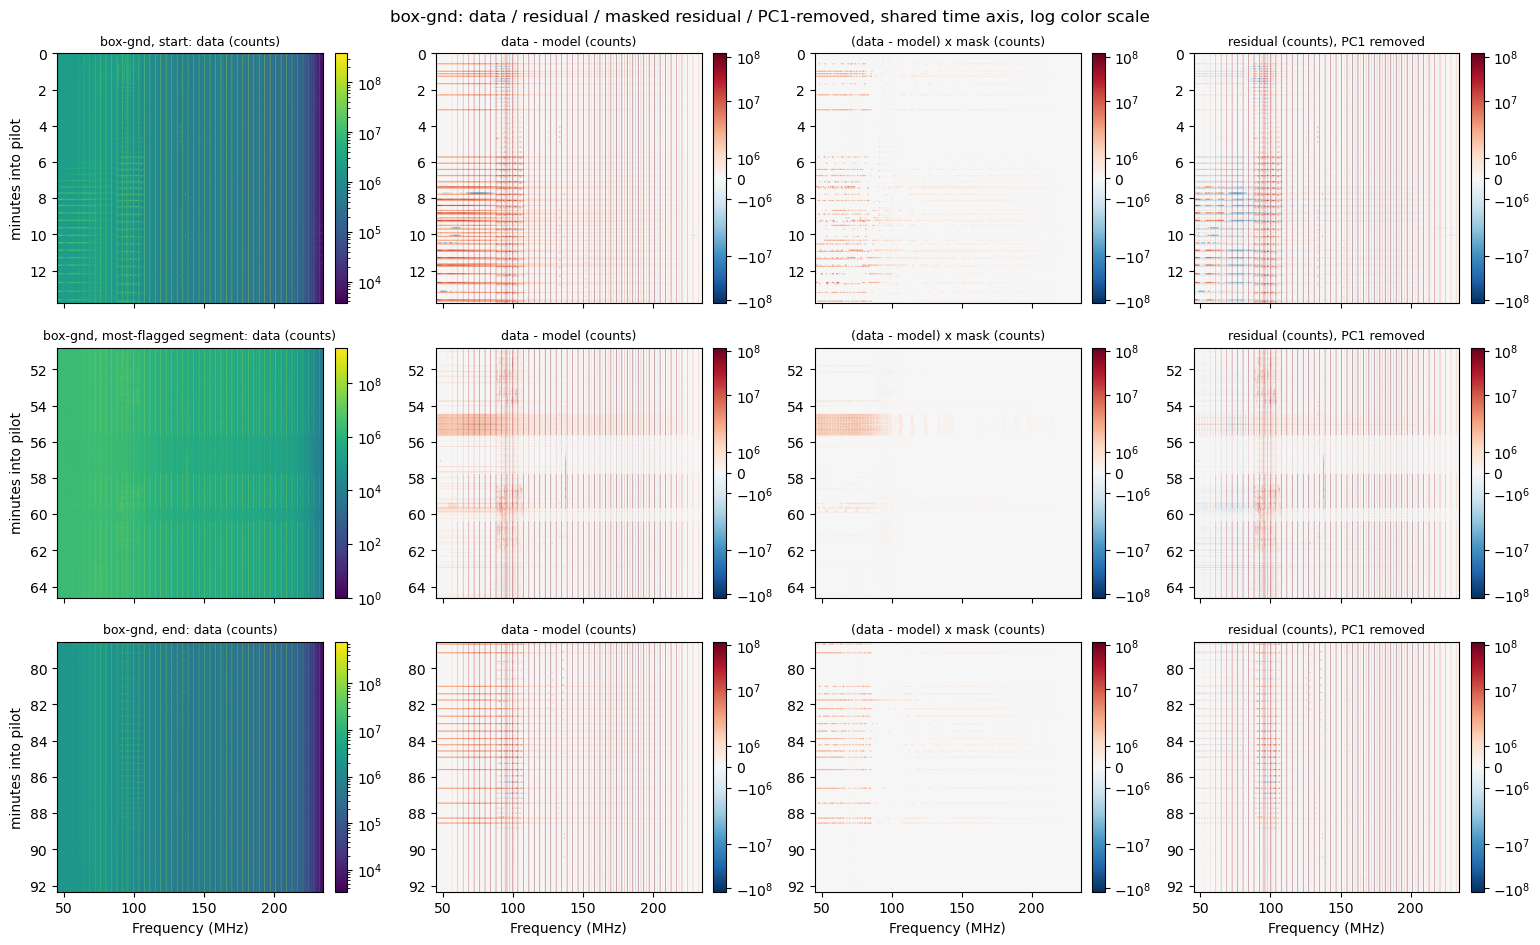

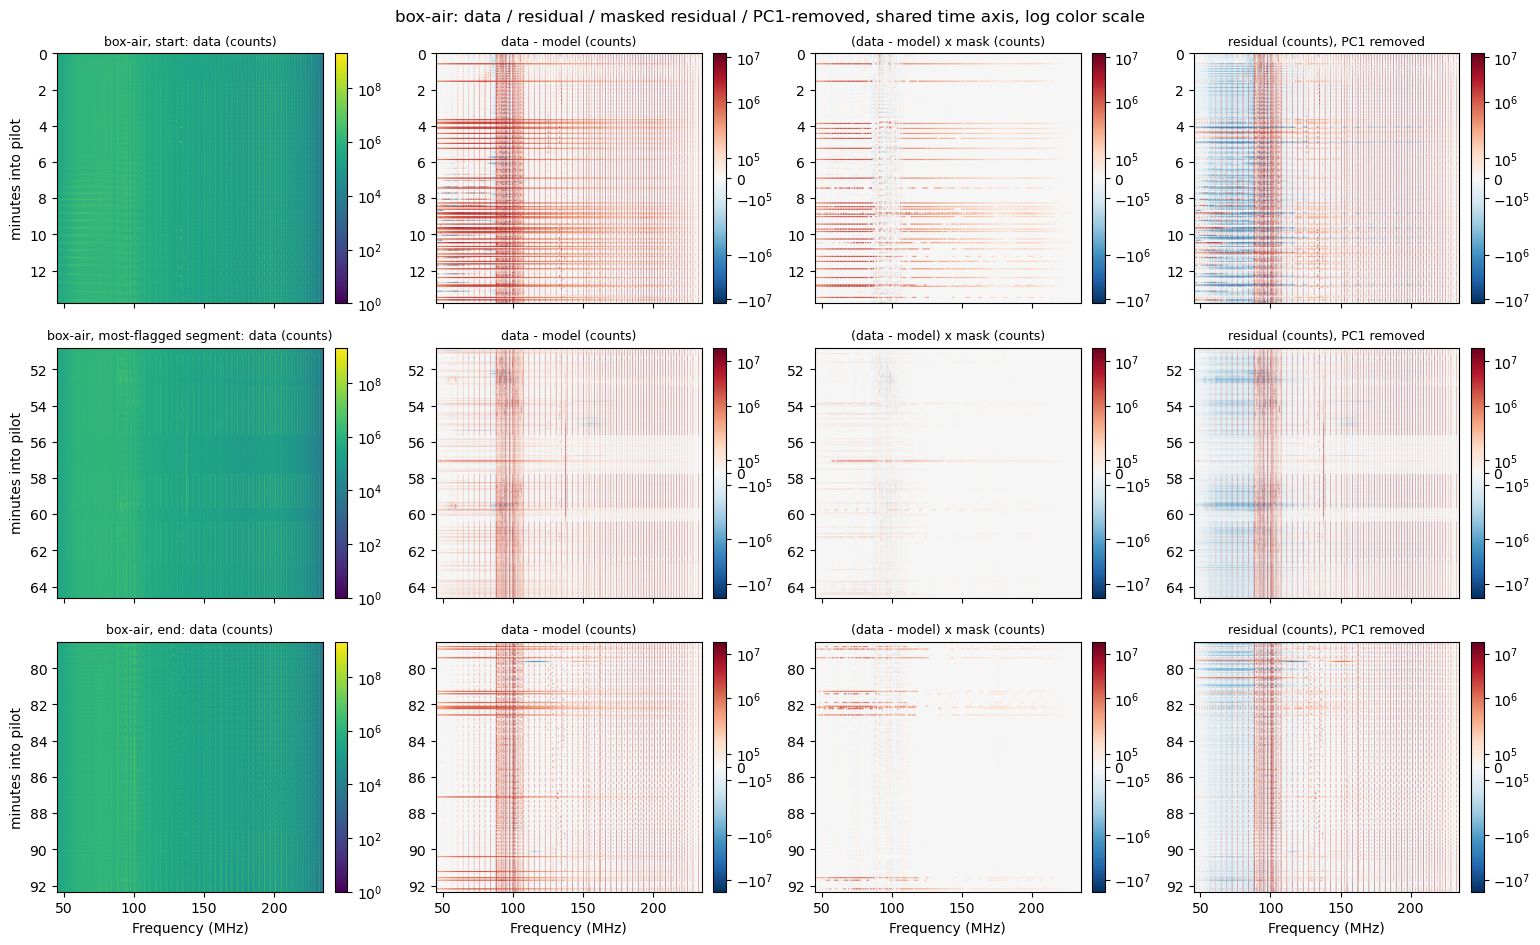

In [10]:

def three_ranges(t):
    t0, t1 = t.min(), t.max()
    span = t1 - t0
    return [
        ("start", t0, t0 + span * 0.15),
        ("most-flagged segment", t0 + span * 0.55, t0 + span * 0.70),
        ("end", t1 - span * 0.15, t1),
    ]

for inp in INPUTS:
    label = "box-gnd" if inp == "0" else "box-air"
    data, model, flag, t = waterfalls[inp]
    resid_lin = data - model  # linear-count residual (rev 4), for the PC1-removal panel
    pc1 = eigvecs_by_input[inp][1][0]  # top masked-PCA eigenvector, unit-normalized
    coeff = resid_lin @ pc1  # project onto PC1 (zeros at flagged pixels contribute ~0)
    resid_minus_pc1 = resid_lin - np.outer(coeff, pc1)

    ranges = three_ranges(t)
    fig, axes = plt.subplots(len(ranges), 4, figsize=(15.5, 3.2 * len(ranges)), sharex="col")
    for row, (tag, lo, hi) in enumerate(ranges):
        sel = (t >= lo) & (t <= hi)
        minutes = (t[sel] - t.min()) / 60
        extent = [freqs_band_mhz.min(), freqs_band_mhz.max(), minutes.max(), minutes.min()]

        d = np.maximum(data[sel], 1)
        mdl_lin = np.maximum(model[sel], 1)
        r_lin = d - mdl_lin  # linear-count residual -- same units as the data panel
        rm_lin = r_lin * (1 - flag[sel])  # panel 3: residual x mask, literally

        im0 = axes[row, 0].imshow(d, aspect="auto", extent=extent,
                                    norm=mcolors.LogNorm(vmin=max(d.min(),1), vmax=d.max()),
                                    cmap="viridis")
        axes[row, 0].set_title(f"{label}, {tag}: data (counts)", fontsize=9)
        fig.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)

        vmax_r = np.percentile(np.abs(r_lin), 99) or 1e-3
        im1 = axes[row, 1].imshow(r_lin, aspect="auto", extent=extent,
                                    norm=mcolors.SymLogNorm(linthresh=vmax_r/50, vmin=-vmax_r, vmax=vmax_r),
                                    cmap="RdBu_r")
        axes[row, 1].set_title("data - model (counts)", fontsize=9)
        fig.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

        im2 = axes[row, 2].imshow(rm_lin, aspect="auto", extent=extent,
                                    norm=mcolors.SymLogNorm(linthresh=vmax_r/50, vmin=-vmax_r, vmax=vmax_r),
                                    cmap="RdBu_r")
        axes[row, 2].set_title("(data - model) x mask (counts)", fontsize=9)
        fig.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

        rp = resid_minus_pc1[sel]
        vmax_p = np.percentile(np.abs(rp), 99) or 1e-3
        im3 = axes[row, 3].imshow(rp, aspect="auto", extent=extent,
                                    norm=mcolors.SymLogNorm(linthresh=vmax_p/50, vmin=-vmax_p, vmax=vmax_p),
                                    cmap="RdBu_r")
        axes[row, 3].set_title("residual (counts), PC1 removed", fontsize=9)
        fig.colorbar(im3, ax=axes[row, 3], fraction=0.046, pad=0.04)

        axes[row, 0].set_ylabel("minutes into pilot")
        if row == len(ranges) - 1:
            for c in range(4):
                axes[row, c].set_xlabel("Frequency (MHz)")
    fig.suptitle(f"{label}: data / residual / masked residual / PC1-removed, shared time axis, log color scale")
    plt.tight_layout()
    plt.show()



**Reading these waterfalls:** panel 1 (data, log color, counts) shows
the raw band shape and every comb/RFI feature at full contrast; panel 2
(residual, linear counts) shows what the smooth fit leaves behind,
directly comparable in scale to panel 1; panel 3 (residual x mask)
blanks anything v0 + self-comb + the refinement pass called bad, so
what remains is what the pipeline currently believes is trustworthy
signal; **panel 4 (residual with the top masked-PCA mode projected
out, linear counts)** is where to look for structure hiding underneath
whatever that mode turned out to be in rev 4. Any vertical banding that
survives into panel 3 across a wide time range is either real
narrowband structure the pipeline has decided to trust, or a gap in the
flagging -- distinguishing the two is what panel 3 is for.



## Decision requested

**Rev 4 correction, checked against actual re-executed output, not
assumed to have worked:** fit, residual, and PCA now operate on linear
amplitude (raw counts), per Aaron's direct correction that log-domain
DPSS fitting was an incorrect operation. Log10 is used only where a
plot wants a log axis/colormap. Committed on `rfi-b16-linear-refit`
(isolated worktree, not merged).

**What changed as a result, measured on the same 28-file pilot, not
assumed:**
1. **Refinement (`REFINE_NSIG=6`, deliberately left untouched per
   Aaron's scoping instruction) over-masks badly in linear domain.**
   8.69% (box-gnd) / 5.27% (box-air) of all pixels newly flagged, vs.
   the ~2% rate rev 2 itself already called "implausible" for a
   6-sigma threshold in log domain. The before/after fair comparison
   flips from rev 3's 22/28, 23/28 "improved" to **1/28, 0/28** --
   refinement makes the fit worse for nearly every file once done in
   linear amplitude. Reported honestly with the threshold unchanged,
   not retuned -- see the refinement section above for why (a heavier
   right tail in linear residuals than a fixed Gaussian-equivalent
   sigma threshold expects).
2. **`hera_filters.dspec.fourier_filter(mode='dpss_leastsq')` runs
   ~15-35x slower per file on linear counts than on log10-compressed
   data** -- this pilot took ~100s just for the DPSS fits themselves
   (see the refinement cell's timing), where rev 2/3's log-domain
   pilot ran in seconds. A future full-campaign estimate built from
   rev 2/3's timing would need to be redone at the linear-domain rate,
   not reused as-is.
3. **The PCA "fringing" read from rev 3 is not reproduced or refuted,
   just no longer comparable.** Mode 1's shape changed from flat/
   broadband to concentrated in the lower half of the band, most
   plausibly because `masked_pca`'s unnormalized linear covariance is
   dominated by whichever channels have the largest absolute counts --
   a covariance-scale artifact, not necessarily a physical difference.
   Confirming or refuting fringing would need a per-channel-normalized
   covariance or a check against terrain/geometry, neither done here.
4. **Unaffected by the domain fix:** the all-zero-model `hera_filters`
   edge case at 100%-flagged rows (same in rev 2/3 and rev 4); the
   135.7/125.5 MHz mask-verification check (91.5%/86.3% unflagged by
   v0, consistent with rev 2/3's 86-92%); the waterfall/mask
   mechanics themselves.

**Not self-assigned, awaiting direction:** whether `REFINE_NSIG` or the
per-channel MAD scale should be revisited for linear residuals (Aaron's
explicit instruction was to keep this pass scoped to the domain fix
alone); whether `masked_pca` should be normalized per-channel before
trusting any linear-domain mode shape; the full-campaign go/no-go
(now confounded by both the runtime and over-masking findings above);
confirming or refuting the fringing interpretation against
terrain/geometry.

**STOPPED AT REVIEW GATE — awaiting Aaron's approval.**
